In [5]:
# confirm environment (C:\Users\mitch\source\repos\mtg_ai\.venv\Scripts\python.exe)

import sys
print(sys.executable)

C:\Users\mitch\source\repos\mtg_ai\.venv\Scripts\python.exe


In [6]:
# Imports & display config

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Make pandas usable for wide MTG data
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 0)

PROJECT_ROOT = Path("..").resolve()
DATA = PROJECT_ROOT / "data" / "processed"

In [7]:
# Load datasets

cards_core = pd.read_parquet(DATA / "cards_core.parquet")
cards_enriched = pd.read_parquet(DATA / "cards_enriched.parquet")
type_features = pd.read_parquet(DATA / "type_features.parquet")
oracle_tokens = pd.read_parquet(DATA / "oracle_tokens.parquet")
clusters = pd.read_parquet(DATA / "oracle_clusters.parquet")
cluster_report = pd.read_parquet(DATA / "cluster_report.parquet")
cluster_reps = pd.read_parquet(DATA / "cluster_representatives.parquet")

print("Loaded:")
print("cards_core:", cards_core.shape)
print("cards_enriched:", cards_enriched.shape)
print("type_features:", type_features.shape)
print("oracle_tokens:", oracle_tokens.shape)
print("clusters:", clusters.shape)

Loaded:
cards_core: (36708, 19)
cards_enriched: (36708, 23)
type_features: (36708, 8)
oracle_tokens: (36708, 5)
clusters: (36708, 2)


In [10]:
# cluster_report.head(10)

In [11]:
# cluster_reps[cluster_reps["cluster"] == 17]

In [12]:
num_clusters = clusters["cluster"].nunique()
print("Number of clusters:", num_clusters)

Number of clusters: 200


In [13]:
sizes = clusters["cluster"].value_counts()
print("Largest cluster size:", sizes.max())
print("Smallest cluster size:", sizes.min())
print("Top 10 cluster sizes:\n", sizes.head(10))

Largest cluster size: 3896
Smallest cluster size: 26
Top 10 cluster sizes:
 cluster
4     3896
61     493
70     431
96     409
99     388
67     387
12     372
68     336
43     326
24     321
Name: count, dtype: int64


In [4]:
cards = cards_enriched.merge(clusters, on="id", how="left")
cards = cards.merge(
    oracle_tokens[["id", "oracle_tokens"]],
    on="id",
    how="left"
)

print(cards.shape)
cards.head(3)

(36708, 25)


,id,oracle_id,name,released_at,lang,layout,type_line,oracle_text,mana_cost,colors,color_identity,keywords,legalities,set,set_name,rarity,cmc,power,toughness,oracle_text_norm,basic_types,super_types,sub_types,cluster,oracle_tokens
0,a471b306-4941-4e46-a0cb-d92895c16f8a,00037840-6089-42ec-8c5c-281f9f474504,"Nissa, Worldsoul Speaker",2025-02-14,en,normal,Legendary Creature — Elf Druid,"Landfall — Whenever a land you control enters, you get {E}{E} (two energy counters).\nYou may pay eight {E} rather t...",{3}{G},[G],[G],[Landfall],"{'alchemy': 'not_legal', 'brawl': 'not_legal', 'commander': 'legal', 'duel': 'legal', 'future': 'not_legal', 'gladia...",drc,Aetherdrift Commander,rare,4.0,3,3,"Landfall — Whenever a land you control enters, you get {E}{E} (two energy counters).\nYou may pay eight {E} rather t...",[Creature],[Legendary],"[Elf, Druid]",148,"[landfall, —, whenever, a, land, you, control, enters, you, get, MANA_SYMBOL, MANA_SYMBOL, (two, energy, counters), ..."
1,6b7baaa7-67f2-4902-a4c1-761d58cce1d4,000492bf-7eaa-4939-a51c-4eef74e4c1d1,Mine Security,2025-08-19,en,normal,Creature — Kavu Soldier,"Trample\nWhen this creature enters, conjure a card named Flametongue Kavu into the top eight cards of your library a...",{1}{R},[R],[R],"[Trample, Conjure]","{'alchemy': 'legal', 'brawl': 'legal', 'commander': 'not_legal', 'duel': 'not_legal', 'future': 'not_legal', 'gladia...",yeoe,Alchemy: Edge of Eternities,uncommon,2.0,3,1,"Trample\nWhen this creature enters, conjure a card named Flametongue Kavu into the top eight cards of your library a...",[Creature],[],"[Kavu, Soldier]",122,"[trample, NEWLINE, when, this, creature, enters, conjure, a, card, named, flametongue, kavu, into, the, top, eight, ..."
2,86bf43b1-8d4e-4759-bb2d-0b2e03ba7012,0004ebd0-dfd6-4276-b4a6-de0003e94237,Static Orb,2001-04-11,en,normal,Artifact,"As long as this artifact is untapped, players can't untap more than two permanents during their untap steps.",{3},[],[],[],"{'alchemy': 'not_legal', 'brawl': 'not_legal', 'commander': 'legal', 'duel': 'legal', 'future': 'not_legal', 'gladia...",7ed,Seventh Edition,rare,3.0,None,None,"As long as this artifact is untapped, players can't untap more than two permanents during their untap steps.",[Artifact],[],[],91,"[as_long_as, this, artifact, is, untapped, players, can't, untap, more, than, two, permanents, during, their, untap,..."


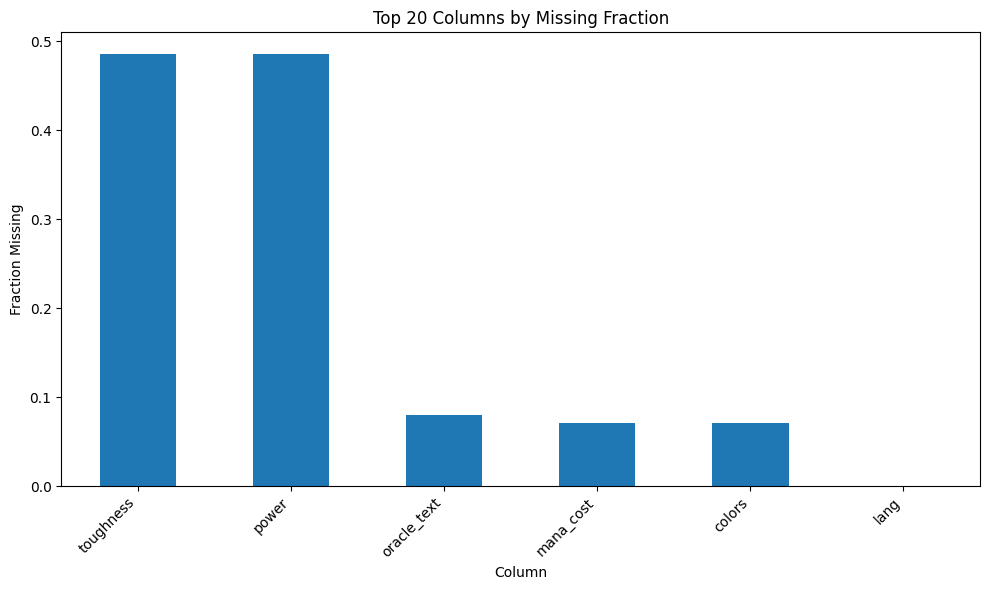

In [5]:
missing = (
    cards.isna()
    .mean()
    .sort_values(ascending=False)
    .head(6)
)

plt.figure(figsize=(10, 6))
missing.plot(kind="bar")
plt.title("Top 20 Columns by Missing Fraction")
plt.ylabel("Fraction Missing")
plt.xlabel("Column")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

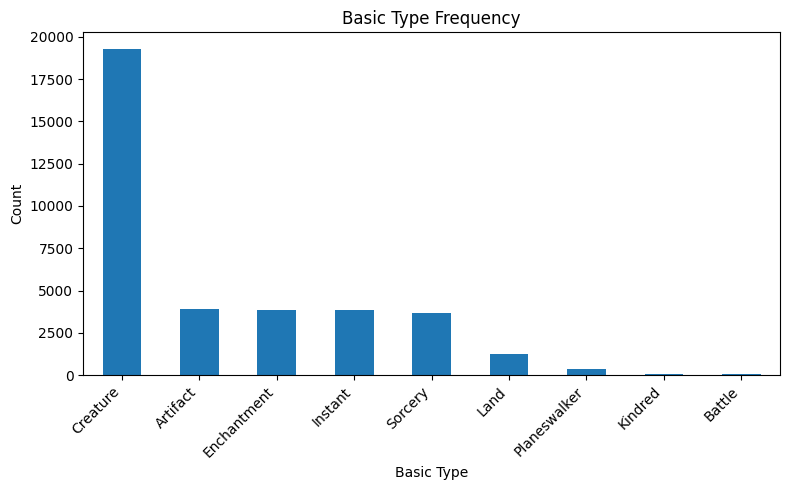

In [6]:
type_counts = (
    type_features["basic_types"]
    .explode()
    .value_counts()
)

plt.figure(figsize=(8, 5))
type_counts.plot(kind="bar")
plt.title("Basic Type Frequency")
plt.ylabel("Count")
plt.xlabel("Basic Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [7]:
cmc_counts = (
    cards["cmc"]
    .dropna()
    .round(0)
    .astype(int)
    .value_counts()
    .sort_index()
)

print(cmc_counts.index.tolist())
print(cmc_counts.index.min(), cmc_counts.index.max())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 1000000]
0 1000000


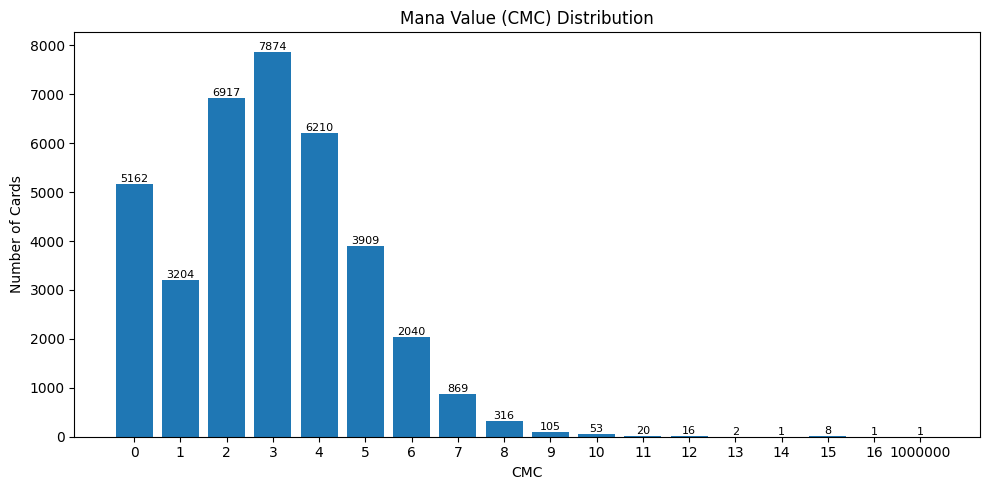

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = range(len(cmc_counts))
x_labels = cmc_counts.index.astype(str)
y_values = cmc_counts.values

bars = ax.bar(x_pos, y_values)

ax.set_title("Mana Value (CMC) Distribution")
ax.set_xlabel("CMC")
ax.set_ylabel("Number of Cards")
ax.set_xticks(list(x_pos))
ax.set_xticklabels(x_labels)

# Add labels on top of bars
for i, v in enumerate(y_values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

In [17]:
# Clean head() views (select columns)

cards_enriched[
    [
        "name",
        "type_line",
        "basic_types",
        "sub_types",
        "cmc",
        "oracle_text_norm",
    ]
].head(5)

,name,type_line,basic_types,sub_types,cmc,oracle_text_norm
0,"Nissa, Worldsoul Speaker",Legendary Creature — Elf Druid,[Creature],"[Elf, Druid]",4.0,"Landfall — Whenever a land you control enters, you get {E}{E} (two energy counters).\nYou may pay eight {E} rather t..."
1,Mine Security,Creature — Kavu Soldier,[Creature],"[Kavu, Soldier]",2.0,"Trample\nWhen this creature enters, conjure a card named Flametongue Kavu into the top eight cards of your library a..."
2,Static Orb,Artifact,[Artifact],[],3.0,"As long as this artifact is untapped, players can't untap more than two permanents during their untap steps."
3,Sensory Deprivation,Enchantment — Aura,[Enchantment],[Aura],1.0,Enchant creature\nEnchanted creature gets -3/-0.
4,Kavaron Consumed,Sorcery,[Sorcery],[],5.0,You may put an artifact or creature card from your hand onto the battlefield. It perpetually becomes an artifact cre...


In [10]:
# Inspect tokenization quality

oracle_tokens[
    ["name", "oracle_text_norm", "oracle_tokens"]
].sample(5, random_state=42)

,name,oracle_text_norm,oracle_tokens
20917,Caravan Vigil,"Search your library for a basic land card, reveal it, put it into your hand, then shuffle.\nMorbid — You may put tha...","[search, your, library, for, a, basic, land, card, reveal, it, put, it, into, your, hand, then, shuffle, NEWLINE, mo..."
18857,Bishop's Soldier,Lifelink (Damage dealt by this creature also causes you to gain that much life.),"[lifelink, (damage, dealt, by, this, creature, also, causes, you, to, gain, that, much, life, )]"
27507,Raging Kronch,This creature can't attack alone.,"[this, creature, can't, attack, alone]"
35527,"Gonti, Night Minister // Gonti, Night Minister",,[]
29950,Dragon-Style Twins,"Double strike\nProwess (Whenever you cast a noncreature spell, this creature gets +1/+1 until end of turn.)","[double, strike, NEWLINE, prowess, (whenever, you, cast, a, noncreature, spell, this, creature, gets, +1/+1, until_e..."


In [11]:
# Look at a single known card

oracle_tokens[oracle_tokens["name"] == "Lightning Bolt"][
    ["oracle_text_norm", "oracle_tokens"]
]

,oracle_text_norm,oracle_tokens
9748,this card deals 3 damage to any target.,"[this, card, deals, NUM:3, damage, to, any, target]"


In [12]:
# Inspect type parsing edge cases

type_features.sample(10, random_state=1)[
    ["name", "type_line", "basic_types", "super_types", "sub_types"]
]

,name,type_line,basic_types,super_types,sub_types
18046,Working Stiff,Creature — Mummy,[Creature],[],[Mummy]
2363,"Appa, Aang's Companion // Appa, Aang's Companion",Card // Card,[],"[Card, Card]",[]
15175,Flight,Enchantment — Aura,[Enchantment],[],[Aura]
8632,Fleshtaker // Fleshtaker,Card // Card,[],"[Card, Card]",[]
22145,Drone,Token Artifact Creature — Drone,"[Artifact, Creature]",[Token],[Drone]
13942,Nekrataal Avatar,Vanguard,[],[Vanguard],[]
12824,Chandra's Spitfire,Creature — Elemental,[Creature],[],[Elemental]
15114,Guise of Fire,Enchantment — Aura,[Enchantment],[],[Aura]
32487,Traumatize,Sorcery,[Sorcery],[],[]
8621,Auratouched Mage,Creature — Human Wizard,[Creature],[],"[Human, Wizard]"


In [13]:
# Test problem children

type_features[type_features["name"].isin([
    "Dryad Arbor",
    "Urza, Lord High Artificer",
    "Fire // Ice",
    "Westvale Abbey"
])][
    ["name", "type_line", "basic_types", "super_types", "sub_types", "type_faces"]
]

,name,type_line,basic_types,super_types,sub_types,type_faces
24929,Fire // Ice,Instant // Instant,"[Instant, Instant]",[],[],"[{'basic_types': ['Instant'], 'raw_face_type_line': 'Instant', 'sub_types': [], 'super_types': []}, {'basic_types': ..."
33284,"Urza, Lord High Artificer",Legendary Creature — Human Artificer,[Creature],[Legendary],"[Human, Artificer]","[{'basic_types': ['Creature'], 'raw_face_type_line': 'Legendary Creature — Human Artificer', 'sub_types': ['Human', ..."
33439,Dryad Arbor,Land Creature — Forest Dryad,"[Land, Creature]",[],"[Forest, Dryad]","[{'basic_types': ['Land', 'Creature'], 'raw_face_type_line': 'Land Creature — Forest Dryad', 'sub_types': ['Forest',..."


In [14]:
# Merge clusters for inspection

clusters = pd.read_parquet(DATA / "oracle_clusters.parquet")

cards_with_clusters = (
    cards_enriched
    .merge(clusters, on="id", how="left")
)

cards_with_clusters[["name", "type_line", "cluster"]].head()

,name,type_line,cluster
0,"Nissa, Worldsoul Speaker",Legendary Creature — Elf Druid,148
1,Mine Security,Creature — Kavu Soldier,122
2,Static Orb,Artifact,91
3,Sensory Deprivation,Enchantment — Aura,54
4,Kavaron Consumed,Sorcery,64


In [15]:
# Inspect a single cluster

cluster_id = 17  # change this

cards_with_clusters[cards_with_clusters["cluster"] == cluster_id][
    ["name", "type_line", "oracle_text_norm"]
].head(20)

,name,type_line,oracle_text_norm
64,Dungeon Delver,Legendary Enchantment — Background,"Commander creatures you own have ""Room abilities of dungeons you own trigger an additional time."""
75,Brawn,Creature — Incarnation,"Trample\nAs long as this card is in your graveyard and you control a Forest, creatures you control have trample."
116,Furnace Oriflamme,Enchantment,"Creatures you control get +1/+0.\nIf you're on the Mirran team, creatures you control have haste.\nIf you're on the ..."
1464,Hag of Mage's Doom,Creature — Hag Warlock,"Warlocks you control have ""Ward—Pay 2 life."""
2682,Cyberdrive Awakener,Artifact Creature — Construct,"Flying\nOther artifact creatures you control have flying.\nWhen this creature enters, each noncreature artifact you ..."
2695,"Smellerbee, Rebel Fighter",Legendary Creature — Human Rebel Ally,"First strike\nOther creatures you control have haste.\nWhenever Smellerbee attacks, you may discard your hand. If yo..."
2711,"Maha, Its Feathers Night",Legendary Creature — Elemental Bird,"Flying, trample\nWard—Discard a card.\nCreatures your opponents control have base toughness 1."
3162,Orim,Vanguard,Creatures you control have reach.
3392,"Elspeth, Knight-Errant Emblem",Emblem — Elspeth,"Artifacts, creatures, enchantments, and lands you control have indestructible."
3657,The Kami Knight,Legendary Creature — Spirit Warrior,Other creatures you control gain all bonuses conferred by equipment attached to this creature.\nCreatures you contro...


In [16]:
# Cluster size distribution

cards_with_clusters["cluster"].value_counts().head(20)

cluster
4      3896
61      493
70      431
96      409
99      388
67      387
12      372
68      336
43      326
24      321
22      313
167     309
126     307
2       299
79      292
109     291
195     290
86      290
130     288
23      286
Name: count, dtype: int64

In [18]:
cards_core["oracle_id"].nunique() == len(cards_core)

True

In [19]:
cards_core["layout"].value_counts()

layout
normal                32038
art_series             2041
token                   896
transform               401
planar                  207
saga                    160
adventure               153
split                   134
vanguard                107
scheme                  102
modal_dfc                96
emblem                   86
double_faced_token       80
mutate                   34
class                    30
flip                     26
leveler                  26
prototype                21
meld                     21
host                     20
case                     15
augment                  14
Name: count, dtype: int64